<a href="https://colab.research.google.com/github/Matheus0820/Aprendizado-de-Maquina/blob/main/unidade01/codes/NLP_em_uma_base_de_dados_de_coment%C3%A1rio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Indentificando se o comentário é bom, ruim ou neutro utilizando Processamento de Linguagem Natural (NLP)

Aprendizado de Máquina 26.1
**Aluno:** Matheus Ramos Ferreira da Silva

## Importando dados

In [1]:
# Bibliotecas
import pandas as pd

url = 'https://raw.githubusercontent.com/Matheus0820/Aprendizado-de-Maquina/refs/heads/main/unidade01/datasets/jardim_botanico_Curitiba_PR.csv'

df = pd.read_csv(url, sep=';', on_bad_lines='skip')
df.head()

,comentario,nota,data
0,O belo Jardim Botânico de Curitiba fica locali...,5.0,fev de 2023
1,"Simplesmente maravilhoso, super organizado, li...",5.0,fev de 2023
2,Imperdível. Rende fotos excelentes se tiver um...,5.0,mar de 2023
3,Um dos mais belos locais de curitiba! Com esta...,5.0,mar de 2023
4,"O lugar é maravilhoso, pra você que é turista ...",5.0,fev de 2023


## Tratando dados
Fazendo com que a depender das notas classifiquemos os comentários como bons, ruins ou neutro.

- Bom → 4 a 5
- Neutro → 3
- Ruim → 1 a 2


In [2]:
import numpy as np

conditions = [
    df['nota'] >= 4,
    df['nota'] == 3
]
choices = ['bom', 'neutro']
df['classificacao'] = np.select(conditions, choices, default='ruim')

df.head()

,comentario,nota,data,classificacao
0,O belo Jardim Botânico de Curitiba fica locali...,5.0,fev de 2023,bom
1,"Simplesmente maravilhoso, super organizado, li...",5.0,fev de 2023,bom
2,Imperdível. Rende fotos excelentes se tiver um...,5.0,mar de 2023,bom
3,Um dos mais belos locais de curitiba! Com esta...,5.0,mar de 2023,bom
4,"O lugar é maravilhoso, pra você que é turista ...",5.0,fev de 2023,bom


# Baixando a biblioteca Spacy

In [3]:
!pip install spacy

In [4]:
# Instalando modelo
!python -m spacy download pt_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 82.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Vatorizando comentários

In [5]:
# Bibliotecas
import spacy
import numpy as np

# Vetorizando os comentários
comentarios = df['comentario']

# Criando modelo
nlp = spacy.load('pt_core_news_sm')

# Função de vetorização
def vetorizar_comentarios(comentarios):
  comentarios_vetorizados = []
  for comentario in comentarios:
    doc = nlp(comentario)
    comentarios_vetorizados.append(doc.vector)

  return np.array(comentarios_vetorizados)

# Vetorizando comentários
comentarios_vetorizados = vetorizar_comentarios(comentarios)

# Tamanho
print(comentarios_vetorizados.shape)

(20674, 96)


In [6]:
# Mostrando o segundo elemento dos comentários vetorizados
print(comentarios_vetorizados[1])

[ 5.7957298e-01  4.0424213e-01  1.8381444e-01  1.4440445e+00
  4.2742082e-01  2.1273775e-01  7.8111611e-02  1.7781819e+00
  1.1736867e+00 -6.1347026e-01  9.9748206e-01 -6.4558357e-01
 -8.2507205e-01 -1.4498183e-01 -1.5223429e+00  1.1051508e+00
  9.0769750e-01  8.0339116e-05  4.3467978e-01  2.0155098e+00
  9.3708473e-01 -1.8634971e-02  8.6374027e-01 -1.0380770e+00
 -2.0586843e+00 -8.0918473e-01 -1.7652258e-01 -1.1988356e+00
  1.5264040e+00 -1.2659287e-01 -9.5161974e-01  2.3909122e-01
  5.7769412e-01  1.6079795e+00  6.7186219e-01 -5.4030544e-01
 -2.3232558e+00  1.2235907e+00  7.8363627e-01  5.9406018e-01
 -1.2442768e+00  9.8187327e-01 -1.1586164e+00  8.3213586e-01
 -1.3621025e-01 -1.3170846e+00 -3.5156832e+00  4.6255013e-01
  3.3621827e-01  1.2620734e+00  2.7598515e-01 -1.4251721e+00
  6.0930198e-01 -1.2110399e+00  1.3039474e+00 -7.7480853e-01
 -4.4545302e-01 -1.6371199e-01 -1.1967040e+00  1.8780425e-01
 -1.2411820e+00  6.0230333e-01 -4.6579012e-01 -1.5513747e+00
  1.7121240e+00  1.28861

## Divisão da base de dados

In [7]:
# Dividindo em treino e teste
# Biblioteca
from sklearn.model_selection import train_test_split

# Pegando classificação dos comentários
classificacao = df['classificacao']

# Gerando as bases de treino e teste
X_train, X_test, y_train, y_test = train_test_split(comentarios_vetorizados, classificacao, test_size=0.2, random_state=9)

# Tamanho das bases de treino e teste criadas
print(f"Tamanho da base de treino: {X_train.shape}")
print(f"Tamanho da base de teste: {X_test.shape}")

Tamanho da base de treino: (16539, 96)
Tamanho da base de teste: (4135, 96)


## Treinando o modelo do Random Forest

In [8]:
# Biblioteca
from sklearn.ensemble import RandomForestClassifier

# Criando e treinando o modelo
modelo = RandomForestClassifier(n_estimators=100)
modelo.fit(X_train, y_train)


RandomForestClassifier()

## Avaliando o modelo

In [9]:
# Biblioteca
from sklearn.metrics import accuracy_score

# Fazendo previsões
y_pred = modelo.predict(X_test)

# Calculando a acurácia das previsões
acuracia = accuracy_score(y_test, y_pred)

# Mostrando a acurácia
print(f"Acurácia do modelo: {acuracia}")

Acurácia do modelo: 0.9446191051995163


[[3906    0    0]
 [ 213    0    0]
 [  16    0    0]]


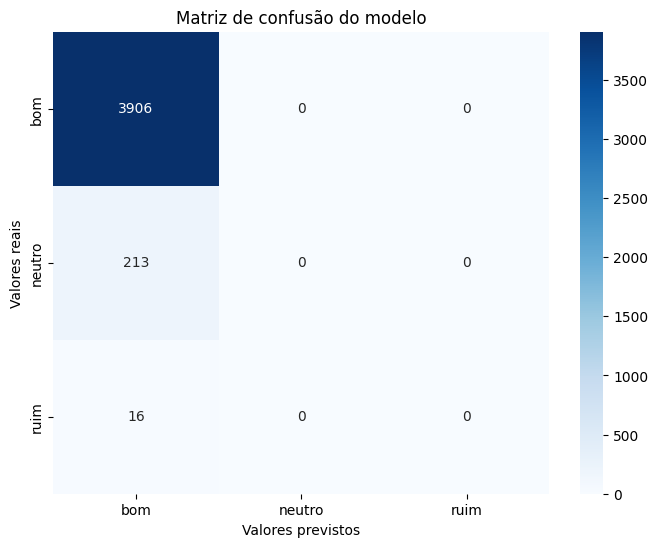

In [13]:
# Matriz de confusão do modelo
# Bibliotecas
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculando a matriz de confusão
matriz_confusao = confusion_matrix(y_test, y_pred)
print(matriz_confusao)

# Mostrando a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', xticklabels=['bom', 'neutro', 'ruim'], yticklabels=['bom', 'neutro', 'ruim'])
plt.xlabel('Valores previstos')
plt.ylabel('Valores reais')
plt.title('Matriz de confusão do modelo')
plt.show()